<a href="https://colab.research.google.com/github/riyamotwanii/AML-Assignments/blob/main/Exp_7_AML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

========== DATASET HEAD ==========

     Income  Credit_Score  Loan_Amount  Employment_Years       Age   Savings  \
0 -0.223972     -2.366013    -0.488679          1.573681  0.911343  0.416648   
1  0.777847     -1.123052     0.594504         -1.413674  2.340408  0.977132   
2 -0.211784      1.278195     0.878723          0.195537 -2.025308 -0.640080   
3 -0.073160      1.472937     0.761690          0.158895 -1.210951 -0.382450   
4  0.026560     -1.457111    -0.052511          1.264830  0.448972 -0.453351   

   Loan_Status  
0            1  
1            1  
2            0  
3            1  
4            0  


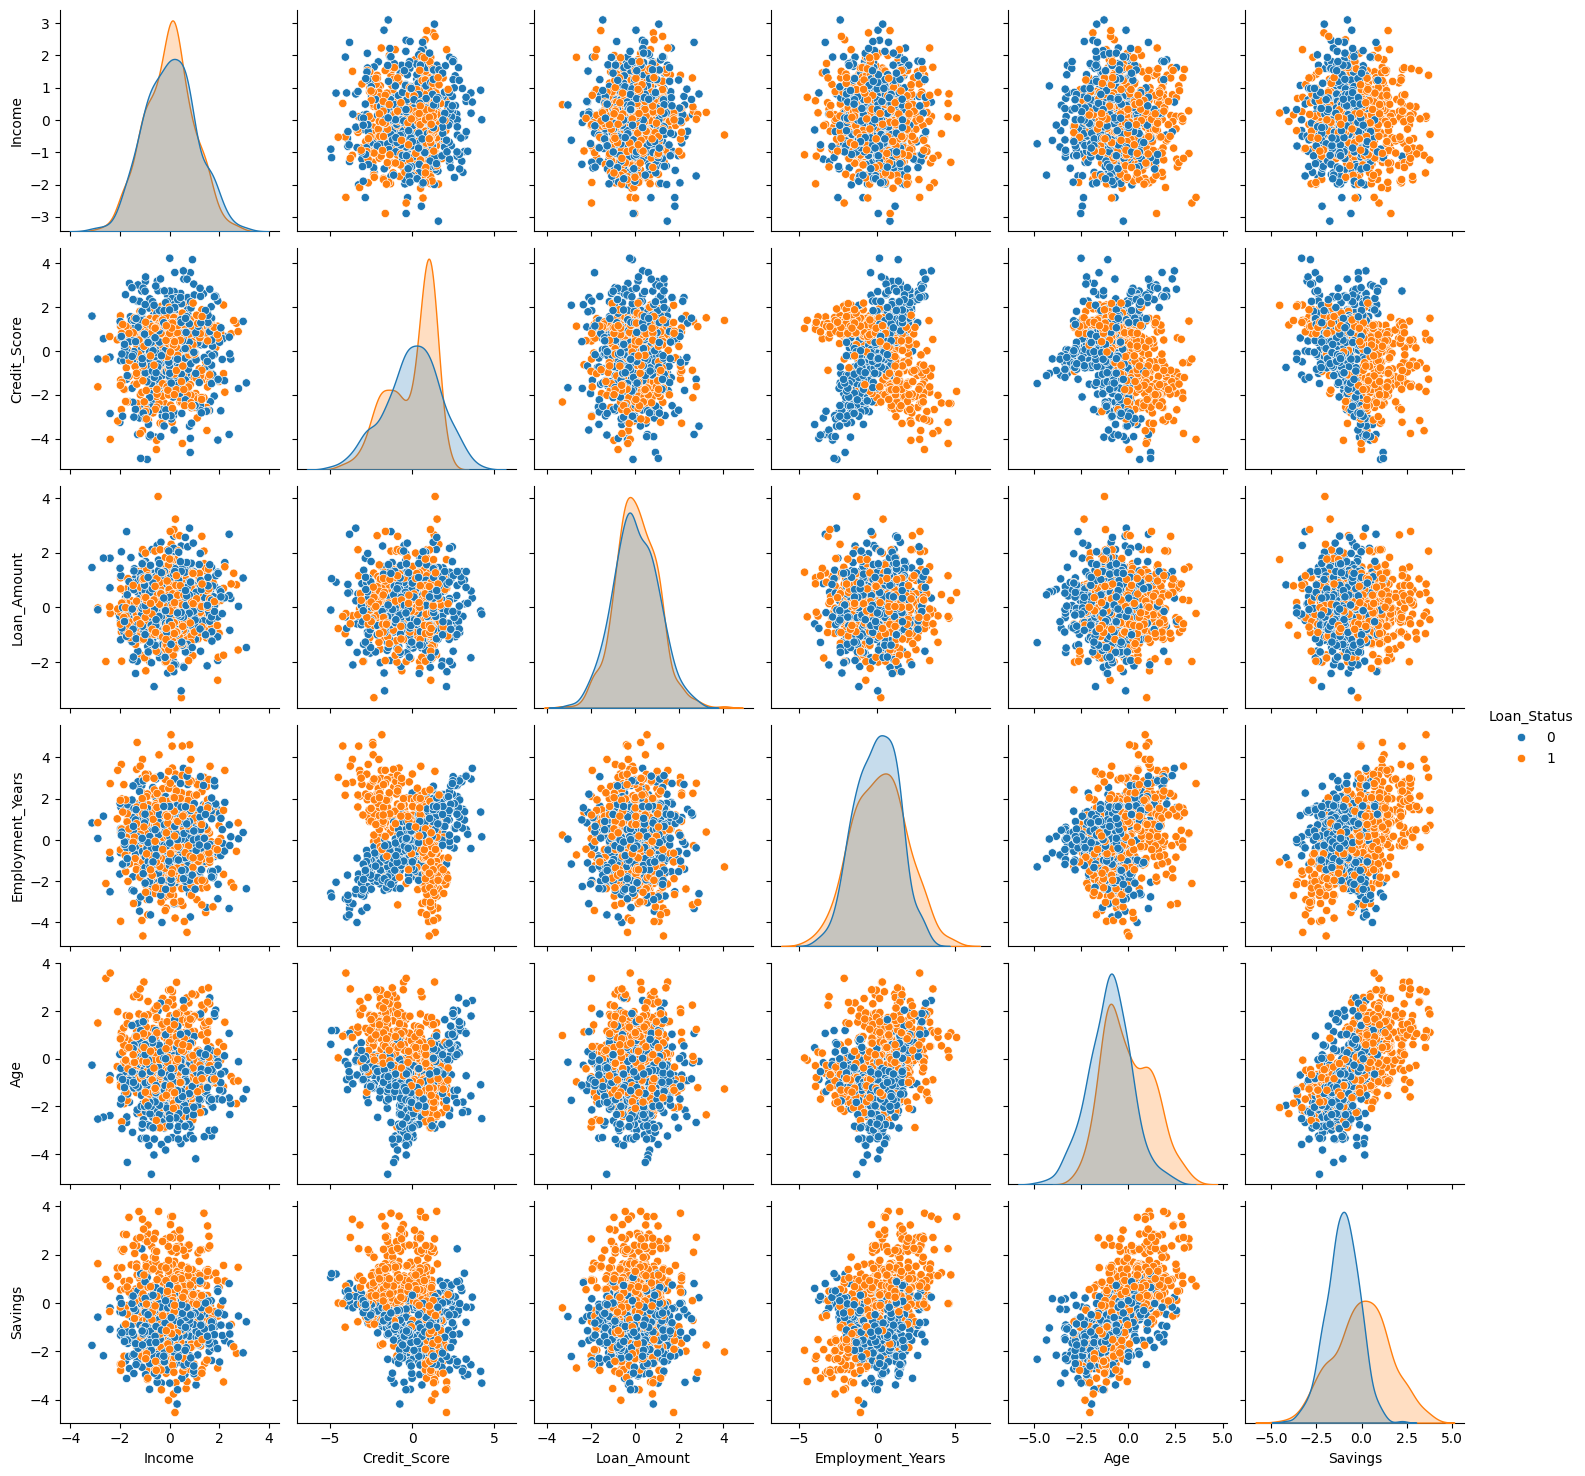

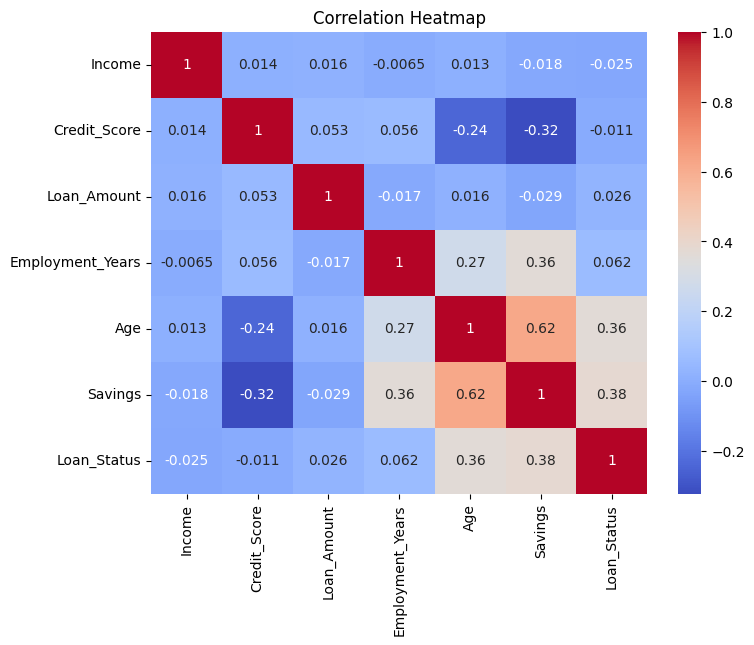


SVM USING LINEAR KERNEL


SVM USING RBF KERNEL


SVM USING POLYNOMIAL KERNEL


HYPERPARAMETER TUNING

Fitting 3 folds for each of 9 candidates, totalling 27 fits
Best Parameters :
{'C': 1, 'gamma': 1, 'kernel': 'rbf'}

MODEL : Linear Kernel

Accuracy  : 74.0 %
Precision : 71.43 %
Recall    : 71.43 %
F1-Score  : 71.43 %

Confusion Matrix :

[[83 26]
 [26 65]]

Classification Report :

              precision    recall  f1-score   support

           0       0.76      0.76      0.76       109
           1       0.71      0.71      0.71        91

    accuracy                           0.74       200
   macro avg       0.74      0.74      0.74       200
weighted avg       0.74      0.74      0.74       200


MODEL : RBF Kernel

Accuracy  : 89.0 %
Precision : 93.67 %
Recall    : 81.32 %
F1-Score  : 87.06 %

Confusion Matrix :

[[104   5]
 [ 17  74]]

Classification Report :

              precision    recall  f1-score   support

           0       0.86      0.95      0.90       109
      

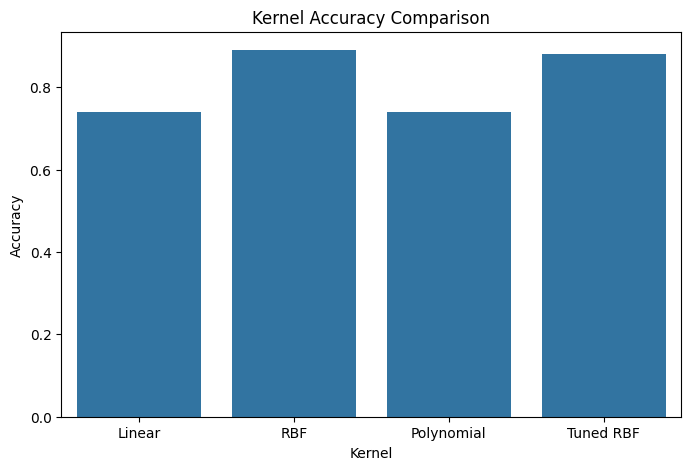


FINAL CONCLUSION

1. SVM models were trained using different kernels.
2. Feature scaling improved SVM performance.
3. Hyperparameter tuning optimized the RBF kernel.
4. Models were evaluated using Accuracy, Precision, Recall and F1-score.
5. The best kernel is the one with highest accuracy and F1-score.


In [ ]:


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# ============================================================
# STEP 2 : CREATE SAMPLE LOAN DATASET
# ============================================================

# Creating synthetic loan approval dataset

X, y = make_classification(
    n_samples=1000,
    n_features=6,
    n_informative=4,
    n_redundant=0,
    n_classes=2,
    random_state=42
)

# Create DataFrame
columns = [
    'Income',
    'Credit_Score',
    'Loan_Amount',
    'Employment_Years',
    'Age',
    'Savings'
]

df = pd.DataFrame(X, columns=columns)

df['Loan_Status'] = y

print("========== DATASET HEAD ==========\n")
print(df.head())

# ============================================================
# STEP 3 : DATA VISUALIZATION
# ============================================================

# Pairplot
sns.pairplot(
    df,
    hue='Loan_Status'
)

plt.show()

# Correlation Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# ============================================================
# STEP 4 : SPLIT FEATURES AND TARGET
# ============================================================

X = df.drop('Loan_Status', axis=1)

y = df['Loan_Status']

# ============================================================
# STEP 5 : TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ============================================================
# STEP 6 : FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# ============================================================
# STEP 7 : TRAIN SVM WITH LINEAR KERNEL
# ============================================================

print("\n================================================")
print("SVM USING LINEAR KERNEL")
print("================================================\n")

linear_svm = SVC(
    kernel='linear',
    C=1
)

linear_svm.fit(X_train_scaled, y_train)

y_pred_linear = linear_svm.predict(X_test_scaled)

# ============================================================
# STEP 8 : TRAIN SVM WITH RBF KERNEL
# ============================================================

print("\n================================================")
print("SVM USING RBF KERNEL")
print("================================================\n")

rbf_svm = SVC(
    kernel='rbf',
    C=1,
    gamma='scale'
)

rbf_svm.fit(X_train_scaled, y_train)

y_pred_rbf = rbf_svm.predict(X_test_scaled)

# ============================================================
# STEP 9 : TRAIN SVM WITH POLYNOMIAL KERNEL
# ============================================================

print("\n================================================")
print("SVM USING POLYNOMIAL KERNEL")
print("================================================\n")

poly_svm = SVC(
    kernel='poly',
    degree=3,
    C=1
)

poly_svm.fit(X_train_scaled, y_train)

y_pred_poly = poly_svm.predict(X_test_scaled)

# ============================================================
# STEP 10 : HYPERPARAMETER TUNING
# ============================================================

print("\n================================================")
print("HYPERPARAMETER TUNING")
print("================================================\n")

param_grid = {
    'C': [0.1, 1, 10],
    'gamma': [1, 0.1, 0.01],
    'kernel': ['rbf']
}

grid = GridSearchCV(
    SVC(),
    param_grid,
    refit=True,
    verbose=1,
    cv=3
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters :")
print(grid.best_params_)

best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test_scaled)



def evaluate_model(y_test, y_pred, model_name):

    print("\n================================================")
    print("MODEL :", model_name)
    print("================================================\n")

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    print("Accuracy  :", round(accuracy * 100, 2), "%")
    print("Precision :", round(precision * 100, 2), "%")
    print("Recall    :", round(recall * 100, 2), "%")
    print("F1-Score  :", round(f1 * 100, 2), "%")

    print("\nConfusion Matrix :\n")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report :\n")
    print(classification_report(y_test, y_pred))

    return accuracy, precision, recall, f1

# ============================================================
# STEP 12 : EVALUATE ALL MODELS
# ============================================================

linear_results = evaluate_model(
    y_test,
    y_pred_linear,
    "Linear Kernel"
)

rbf_results = evaluate_model(
    y_test,
    y_pred_rbf,
    "RBF Kernel"
)

poly_results = evaluate_model(
    y_test,
    y_pred_poly,
    "Polynomial Kernel"
)

best_results = evaluate_model(
    y_test,
    y_pred_best,
    "Tuned RBF Kernel"
)

# ============================================================
# STEP 13 : COMPARE KERNEL PERFORMANCE
# ============================================================

comparison = pd.DataFrame({
    'Kernel': [
        'Linear',
        'RBF',
        'Polynomial',
        'Tuned RBF'
    ],

    'Accuracy': [
        linear_results[0],
        rbf_results[0],
        poly_results[0],
        best_results[0]
    ],

    'Precision': [
        linear_results[1],
        rbf_results[1],
        poly_results[1],
        best_results[1]
    ],

    'Recall': [
        linear_results[2],
        rbf_results[2],
        poly_results[2],
        best_results[2]
    ],

    'F1-Score': [
        linear_results[3],
        rbf_results[3],
        poly_results[3],
        best_results[3]
    ]
})

print("\n================================================")
print("KERNEL PERFORMANCE COMPARISON")
print("================================================\n")

print(comparison)


plt.figure(figsize=(8,5))

sns.barplot(
    x='Kernel',
    y='Accuracy',
    data=comparison
)

plt.title("Kernel Accuracy Comparison")

plt.show()


print("\n================================================")
print("FINAL CONCLUSION")
print("================================================\n")

print("1. SVM models were trained using different kernels.")
print("2. Feature scaling improved SVM performance.")
print("3. Hyperparameter tuning optimized the RBF kernel.")
print("4. Models were evaluated using Accuracy, Precision, Recall and F1-score.")
print("5. The best kernel is the one with highest accuracy and F1-score.")